# 09 · Nonlinear regression: fitting the Antoine equation

**Problem.** Vapour-pressure measurements of a solvent are to be fitted with the Antoine equation
$$\log_{10} p = A - \frac{B}{C + T},$$
which is nonlinear in $C$. Data are generated from Antoine constants commonly tabulated for ethanol
($A$ = 8.20417, $B$ = 1642.89, $C$ = 230.300; $p$ in mmHg, $T$ in °C) with 1 % random error.

**What you will learn**

- fit a nonlinear model and obtain standard errors of its parameters
- follow Levenberg-Marquardt iterations and the role of damping
- interpret parameter correlations and choose starting values
- decide whether an extra parameter is justified

**Before you start:** notebook 08; the idea of a Jacobian (matrix of partial derivatives)  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import fitting
from scipy.optimize import curve_fit

In [2]:
A_t, B_t, C_t = 8.20417, 1642.89, 230.300
T = np.linspace(20, 90, 12)
rng = np.random.default_rng(5)
p = 10**(A_t - B_t/(C_t + T)) * (1 + 0.01*rng.standard_normal(T.size))

def antoine_log(T, A, B, C):
    return A - B/(C + T)

## Fitting with Levenberg-Marquardt
`engmath.fitting.levenberg_marquardt` blends Gauss-Newton (fast near the optimum) with gradient
descent (safe far away). The errors are proportional to $p$, so we fit $\log_{10} p$, which makes them
roughly equal in size (the correct weighting).

A =     7.9291 ±   0.1928   (scipy curve_fit     7.9291)
B =  1487.3496 ± 103.5876   (scipy curve_fit  1487.3495)
C =   216.3272 ±   9.3073   (scipy curve_fit   216.3272)
iterations 8, residual SD 3.91e-03 in log10 p


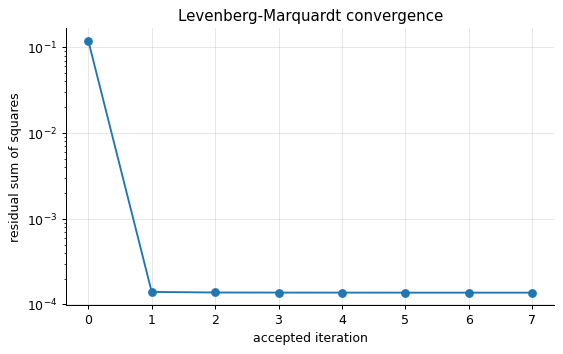

In [3]:
fit = fitting.levenberg_marquardt(antoine_log, T, np.log10(p), p0=[8.0, 1500.0, 220.0])
popt, pcov = curve_fit(antoine_log, T, np.log10(p), p0=[8.0, 1500.0, 220.0])
for name, v, s, ref in zip("ABC", fit.coef, fit.se, popt):
    print(f"{name} = {v:10.4f} ± {s:8.4f}   (scipy curve_fit {ref:10.4f})")
print(f"iterations {fit.iterations}, residual SD {fit.sigma:.2e} in log10 p")
plt.semilogy(fit.history, "o-"); plt.xlabel("accepted iteration"); plt.ylabel("residual sum of squares")
plt.title("Levenberg-Marquardt convergence"); plt.show()

## Inside the algorithm: Levenberg-Marquardt, one iteration at a time
Linearise the model about the current parameters, $f(\mathbf p + \boldsymbol\delta) \approx f(\mathbf p) + J\boldsymbol\delta$,
with the Jacobian $J_{ij} = \partial f(x_i)/\partial p_j$. Least squares on the linearised model gives the
Gauss-Newton step; Levenberg-Marquardt adds damping $\lambda$:
$$\left(J^TJ + \lambda\,\mathrm{diag}(J^TJ)\right)\boldsymbol\delta = J^T\mathbf r .$$
If a step lowers the RSS it is accepted and $\lambda$ is reduced (trust the linearisation more);
otherwise it is rejected and $\lambda$ is increased (shorter, steepest-descent-like steps).

In [4]:
def jacobian_by_hand(f, x, params, rel=1e-7):
    J = np.empty((len(x), len(params)))
    for j in range(len(params)):
        dp = rel * max(abs(params[j]), 1e-8)
        shifted = np.array(params, float)
        shifted[j] += dp
        J[:, j] = (f(x, *shifted) - f(x, *params)) / dp
    return J

y_obs = np.log10(p)
params, lam = np.array([8.0, 1500.0, 220.0]), 1e-3
rss = np.sum((y_obs - antoine_log(T, *params))**2)
for it in range(1, 11):
    J = jacobian_by_hand(antoine_log, T, params)
    A = J.T @ J
    step = np.linalg.solve(A + lam * np.diag(np.diag(A)), J.T @ (y_obs - antoine_log(T, *params)))
    new_rss = np.sum((y_obs - antoine_log(T, *(params + step)))**2)
    if new_rss < rss:
        params, rss, lam, verdict = params + step, new_rss, lam / 10, "accept"
    else:
        lam, verdict = lam * 10, "reject"
    print(f"{it:2d} {verdict}  lambda = {lam:7.1e}  RSS = {rss:.6e}  A, B, C = {np.round(params, 3)}")

 1 accept  lambda = 1.0e-04  RSS = 1.401197e-04  A, B, C = [   7.969 1508.962  218.244]
 2 accept  lambda = 1.0e-05  RSS = 1.379425e-04  A, B, C = [   7.967 1507.779  218.155]
 3 accept  lambda = 1.0e-06  RSS = 1.376130e-04  A, B, C = [   7.953 1500.409  217.498]
 4 accept  lambda = 1.0e-07  RSS = 1.374358e-04  A, B, C = [   7.933 1489.238  216.499]
 5 accept  lambda = 1.0e-08  RSS = 1.373599e-04  A, B, C = [   7.929 1487.377  216.33 ]
 6 accept  lambda = 1.0e-09  RSS = 1.373598e-04  A, B, C = [   7.929 1487.35   216.327]
 7 reject  lambda = 1.0e-08  RSS = 1.373598e-04  A, B, C = [   7.929 1487.35   216.327]
 8 accept  lambda = 1.0e-09  RSS = 1.373598e-04  A, B, C = [   7.929 1487.35   216.327]
 9 accept  lambda = 1.0e-10  RSS = 1.373598e-04  A, B, C = [   7.929 1487.35   216.327]
10 reject  lambda = 1.0e-09  RSS = 1.373598e-04  A, B, C = [   7.929 1487.35   216.327]


Each accepted step lowers the RSS and shrinks $\lambda$, so the method turns into fast Gauss-Newton near
the optimum. Once the RSS cannot improve any further (within rounding error), steps are rejected - the
signal to stop. This loop is the whole algorithm; the library version adds a convergence test, a
guard against non-finite values and the covariance matrix for the standard errors.

## The parameters are nearly impossible to separate
The standard errors are large compared with the precision of the fit. The **correlation matrix**
explains why:

In [5]:
print(np.round(fit.correlation, 4))

[[1.     0.9993 0.9974]
 [0.9993 1.     0.9994]
 [0.9974 0.9994 1.    ]]


Correlations above 0.99 mean that a change in $B$ can be almost perfectly compensated by changes in
$A$ and $C$: many parameter sets describe the data equally well. The *fitted curve* is precise, but
individual parameters are not - so never extrapolate far, and never compare parameters from
different papers one at a time.

This also explains why the fitted $A$, $B$ and $C$ are all about 1.5 standard errors *below* the values
used to generate the data. With correlations this close to 1 the three errors are not independent:
they move together along a valley of almost equally good fits, so one unlucky set of noise shifts all
three at once. Judge a nonlinear fit by the fitted curve and its residuals, not by any single parameter.

## Starting values matter

In [6]:
for p0 in ([8, 1500, 220], [5, 500, 100], [8, 1500, -20]):
    try:
        np.seterr(divide="ignore")                   # the last start divides by zero - on purpose
        r = fitting.levenberg_marquardt(antoine_log, T, np.log10(p), p0=p0)
        print(f"start {p0}: A, B, C = {np.round(r.coef, 3)}, RSS = {r.history[-1]:.2e}")
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"start {p0}: refused - {e}")
np.seterr(divide="warn")

start [8, 1500, 220]: A, B, C = [   7.929 1487.35   216.327], RSS = 1.37e-04
start [5, 500, 100]: A, B, C = [   7.929 1487.35   216.327], RSS = 1.37e-04
start [8, 1500, -20]: refused - The model is not finite at the starting values (e.g. a singularity inside the data range); choose better starting values.


{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

A start with $C = -20$ puts the singularity $C + T = 0$ exactly on the first data point (20 °C): the
model is infinite there and the fit cannot even begin. Poor but finite starts (the second line) are
usually rescued by Levenberg-Marquardt's damping. Good starting values come from physics or from a simpler linearised fit - e.g. the
two-parameter Clausius-Clapeyron form $\log_{10} p = a - b/(T + 273.15)$, which is *linear* in $a, b$.

## Is the third parameter worth it?

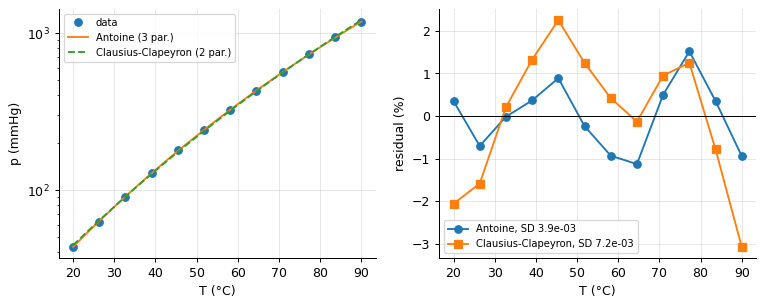

In [7]:
cc = fitting.linear_lstsq(np.column_stack([np.ones(T.size), -1/(T + 273.15)]), np.log10(p))
T_f = np.linspace(20, 90, 200)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.semilogy(T, p, "o", label="data"); a1.semilogy(T_f, 10**antoine_log(T_f, *fit.coef), label="Antoine (3 par.)")
a1.semilogy(T_f, 10**(cc.coef[0] - cc.coef[1]/(T_f + 273.15)), "--", label="Clausius-Clapeyron (2 par.)")
a1.set(xlabel="T (°C)", ylabel="p (mmHg)"); a1.legend(fontsize=8)
a2.plot(T, 100*fit.residuals*np.log(10), "o-", label=f"Antoine, SD {fit.sigma:.1e}")
a2.plot(T, 100*cc.residuals*np.log(10), "s-", label=f"Clausius-Clapeyron, SD {cc.sigma:.1e}")
a2.axhline(0, color="k", lw=0.8); a2.set(xlabel="T (°C)", ylabel="residual (%)"); a2.legend(fontsize=8)
plt.show()

The two-parameter model leaves a systematic pattern in the residuals: the extra parameter is
justified by the physics (temperature-dependent heat of vaporisation), not just by a smaller error.

## Exercises
1. Fit $p$ directly (not $\log p$) with equal weights. Which data points dominate the fit, and how do
   the parameters change?
2. Fix $C$ at 230.3 and fit only $A$ and $B$ - a linear problem. Compare the standard errors with the
   three-parameter fit.
3. Fit the cooling data of notebook 06 by integrating the model instead of differentiating the data:
   fit $\Delta T(t) = [\Delta T_0^{-1/4} + Ct/4]^{-4}$ (generalised to exponent $n$) to the *noisy*
   temperatures. Compare the precision of $n$ with the differential method.
4. **Implement it yourself:** run the hand-written loop for 40 iterations from $(7.5, 1300, 180)$ and count the rejected steps - why does it crawl, given the parameter correlations? Then remove the damping ($\lambda = 0$, pure Gauss-Newton) and try both starting points. What does the damping buy you?